1. Importação das bibliotecas

In [60]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

2. Definição da variável *file* referente ao caminho da base de dados

In [61]:
# Importação do arquivo de tabela a ser utilizado, através do path na seção "Files" do Colab, contendo as informações de resíduos sólidos
file='./Solid_waste_pt.xlsx'

3. Leitura da planilha através do Python

In [62]:
# Visão geral da tabela
df=pd.read_excel(file)
df

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg
0,Zona Sul,Reciclável,Comercial,Aterro Sanitário,1057.3,80.8,2.0,14.7,138.7,79.7,15.1
1,Zona Oeste,Reciclável,Comercial,Reciclagem,533.3,82.4,2.0,9.1,119.1,85.4,17.9
2,Centro,Reciclável,Comercial,Reciclagem,529.7,72.7,2.0,24.0,223.2,81.6,13.9
3,Zona Oeste,Reciclável,Comercial,Reciclagem,486.3,67.4,2.0,3.6,117.9,82.0,18.8
4,Zona Leste,Reciclável,Comercial,Aterro Sanitário,527.1,40.0,2.0,16.7,164.2,88.0,14.7
...,...,...,...,...,...,...,...,...,...,...,...
285,Zona Leste,Orgânico,Residencial,Aterro Sanitário,275.9,371.8,77.0,17.2,178.8,5.2,6.5
286,Zona Norte,Orgânico,Comercial,Aterro Sanitário,471.8,338.4,77.2,52.9,262.3,5.0,8.1
287,Zona Leste,Orgânico,Residencial,Aterro Sanitário,356.3,341.2,77.6,18.0,184.2,10.1,3.6
288,Zona Oeste,Orgânico,Comercial,Reciclagem,674.9,316.9,78.5,5.1,94.1,8.1,8.8


4. Impressão das tabelas

In [63]:
# Tabela que mostra a quantidade de coletas realizadas em cada regiao
df_Origem_Residuo=df.Origem_Residuo.value_counts()
df_Origem_Residuo

,count
Origem_Residuo,
Residencial,143
Comercial,67
Industrial,58
Serviços de Saúde,22


In [64]:
# Impressão do total das coletas realizadas
total_df_Origem_Residuo=df_Origem_Residuo.sum()
total_df_Origem_Residuo

np.int64(290)

In [65]:
# Reinicia os índices da região de coleta
dados_v_Origem_Residuo=pd.DataFrame(df_Origem_Residuo).reset_index()
# Renomeia as colunas na tabela com o total de resíduos coletados em cada região da cidade
dados_v_Origem_Residuo.columns=['Origem do Resíduo','Frequência absoluta']
dados_v_Origem_Residuo

print(dados_v_Origem_Residuo)


   Origem do Resíduo  Frequência absoluta
0        Residencial                  143
1          Comercial                   67
2         Industrial                   58
3  Serviços de Saúde                   22


In [66]:
# Cálculo da frequência relativa
dados_v_Origem_Residuo['Frequência relativa(%)']=round((dados_v_Origem_Residuo['Frequência absoluta']/total_df_Origem_Residuo)*100,2)
print(dados_v_Origem_Residuo)

   Origem do Resíduo  Frequência absoluta  Frequência relativa(%)
0        Residencial                  143                   49.31
1          Comercial                   67                   23.10
2         Industrial                   58                   20.00
3  Serviços de Saúde                   22                    7.59


In [67]:
# Criação de uma tabela com os dados de total de resíduos sólidos de cada região e a frequência relativa de porcentagem de cada região
tabela_Dados_v_Origem_Residuo=pd.DataFrame(dados_v_Origem_Residuo)
tabela_Dados_v_Origem_Residuo

,Origem do Resíduo,Frequência absoluta,Frequência relativa(%)
0,Residencial,143,49.31
1,Comercial,67,23.10
2,Industrial,58,20.00
3,Serviços de Saúde,22,7.59


5. **Gráficos**

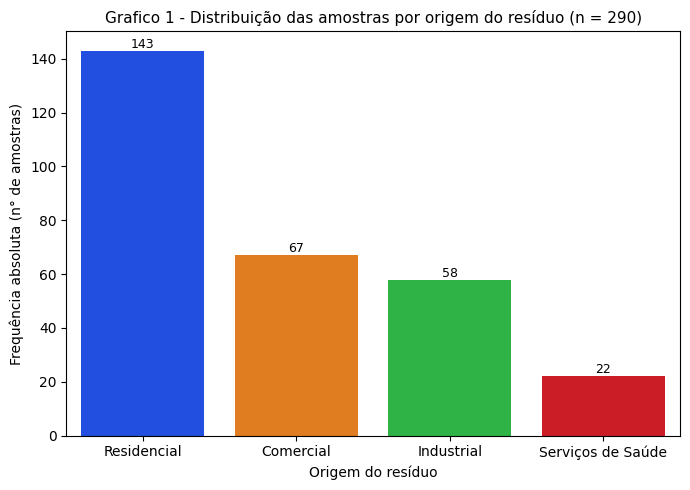

In [69]:
# Grafico de barras final: eixos nomeados, titulo e rotulos de valor
ordem = list(df.Origem_Residuo.value_counts().index)
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(x='Origem_Residuo', data=df, order=ordem, hue='Origem_Residuo',
              hue_order=ordem, palette='bright', legend=False, ax=ax)
ax.set_xlabel("Origem do resíduo", size=10)
ax.set_ylabel("Frequência absoluta (n° de amostras)", size=10)
ax.set_title("Grafico 1 - Distribuição das amostras por origem do resíduo (n = 290)", size=11)
for container in ax.containers:
    ax.bar_label(container, fontsize=9)
plt.tight_layout()
plt.show()

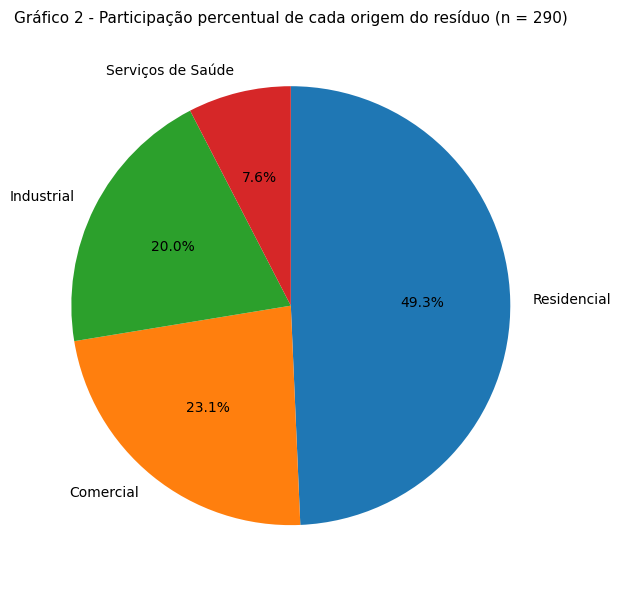

In [70]:
# Grafico de setores: valores lidos diretamente da tabela (evita numeros digitados a mao)
rotulos = list(tabela_Dados_v_Origem_Residuo['Origem do Resíduo'])
valores = list(tabela_Dados_v_Origem_Residuo['Frequência absoluta'])

plt.figure(figsize=(7, 6))
plt.pie(valores, labels=rotulos, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title("Gráfico 2 - Participação percentual de cada origem do resíduo (n = 290)", size=11)
plt.tight_layout()
plt.show()

6. **Medida de tendência central: Moda**

Existem 143 registros de resíduos sólidos de origem residencial na base de dados. Sendo assim, **Residencial** é a categoria da variável de **Origem de Resíduo** que mais se repete ao longo da base de dados.

In [71]:
df.Origem_Residuo.mode()

,Origem_Residuo
0,Residencial


**Medida resumo (moda):** a moda da variável qualitativa nominal **Origem do Residuo** e a categoria **Residencial**, observada em **143 das 290 amostras (49,31%)**. Como a variável é nominal, a moda não possui unidade métrica: ela é expressa na própria categoria, sendo a unidade subjacente da contagem o número de amostras. Media e mediana não são definidas para variáveis nominais.

7. Download da tabela com as variável nominal escolhida

In [72]:
tabela_Dados_v_Origem_Residuo.to_excel("Tabela_Variaveis_Escolhidas.xlsx",sheet_name="Dados",index=False)